In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("../data/processed/credito_limpio.csv")

# --- Paleta y estilo corporativo financiero ---
AZUL_OSCURO  = "#1B2A4A"
AZUL_MEDIO   = "#2E5FA3"
ROJO_MORA    = "#C0392B"
VERDE_OK     = "#1A7A4A"
AMARILLO     = "#F39C12"
GRIS_FONDO   = "#F4F6F9"
GRIS_TEXTO   = "#555555"

COLORES_RIESGO = {
    "Alto"  : ROJO_MORA,
    "Medio" : AMARILLO,
    "Bajo"  : VERDE_OK
}

plt.rcParams.update({
    "figure.facecolor"  : GRIS_FONDO,
    "axes.facecolor"    : "white",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.labelcolor"   : GRIS_TEXTO,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
    "axes.titlecolor"   : AZUL_OSCURO,
    "xtick.color"       : GRIS_TEXTO,
    "ytick.color"       : GRIS_TEXTO,
    "font.family"       : "sans-serif",
    "grid.color"        : "#E0E0E0",
    "grid.linestyle"    : "--",
    "grid.linewidth"    : 0.7,
})

print("✅ Estilo corporativo configurado")

✅ Estilo corporativo configurado


✅

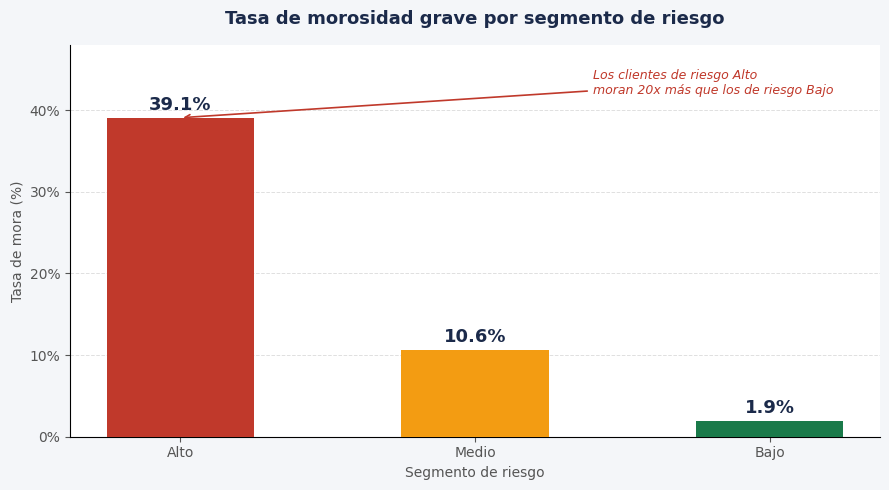

✅ Gráfico guardado


In [ ]:
segmentos = df.groupby("segmento_riesgo").agg(
    total        = ("mora_grave", "count"),
    en_mora      = ("mora_grave", "sum")
).reset_index()
segmentos["tasa_mora"] = segmentos["en_mora"] / segmentos["total"] * 100
segmentos = segmentos.set_index("segmento_riesgo").loc[["Alto","Medio","Bajo"]].reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(GRIS_FONDO)

bars = ax.bar(
    segmentos["segmento_riesgo"],
    segmentos["tasa_mora"],
    color  = [COLORES_RIESGO[s] for s in segmentos["segmento_riesgo"]],
    width  = 0.5,
    zorder = 3
)

# Etiquetas encima de cada barra
for bar, val in zip(bars, segmentos["tasa_mora"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.1f}%",
        ha="center", va="bottom",
        fontsize=13, fontweight="bold", color=AZUL_OSCURO
    )

ax.set_title("Tasa de morosidad grave por segmento de riesgo", pad=15)
ax.set_ylabel("Tasa de mora (%)")
ax.set_xlabel("Segmento de riesgo")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.set_ylim(0, 48)
ax.grid(axis="y", zorder=0)

# Anotación ejecutiva
ax.annotate(
    "Los clientes de riesgo Alto\nmoran 20x más que los de riesgo Bajo",
    xy=(0, 39.07), xytext=(1.4, 42),
    fontsize=9, color=ROJO_MORA, style="italic",
    arrowprops=dict(arrowstyle="->", color=ROJO_MORA, lw=1.2)
)
print(" 📊 Gráfico generado")    
plt.tight_layout()
plt.savefig("../reports/01_mora_por_segmento.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráfico guardado")

 📊 Gráfico generado


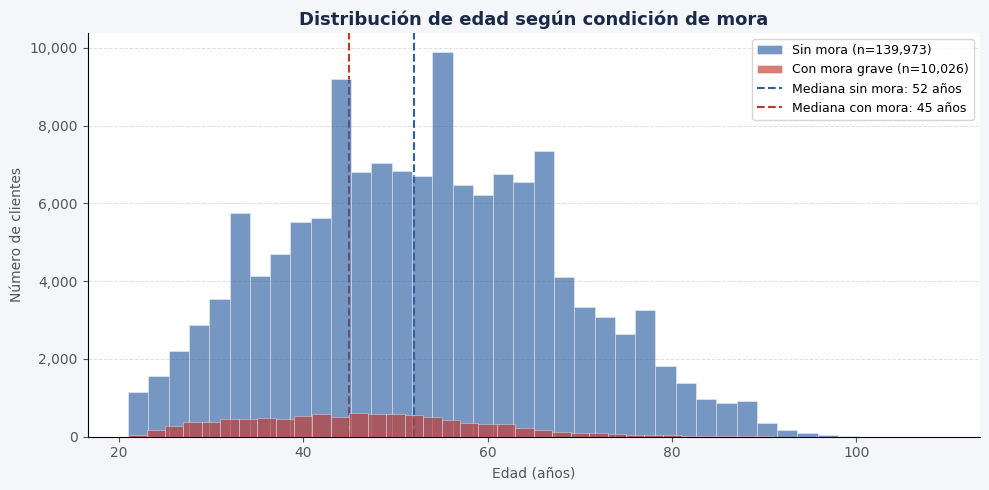

 📊 Gráfico generado


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(GRIS_FONDO)

for condicion, color, label in [
    (0, AZUL_MEDIO, "Sin mora"),
    (1, ROJO_MORA,  "Con mora grave")
]:
    subset = df[df["mora_grave"] == condicion]["edad"]
    ax.hist(
        subset, bins=40, alpha=0.65,
        color=color, label=f"{label} (n={len(subset):,})",
        edgecolor="white", linewidth=0.4, zorder=3
    )

ax.axvline(
    df[df["mora_grave"]==0]["edad"].median(),
    color=AZUL_MEDIO, linestyle="--", lw=1.5,
    label=f'Mediana sin mora: {df[df["mora_grave"]==0]["edad"].median():.0f} años'
)
ax.axvline(
    df[df["mora_grave"]==1]["edad"].median(),
    color=ROJO_MORA, linestyle="--", lw=1.5,
    label=f'Mediana con mora: {df[df["mora_grave"]==1]["edad"].median():.0f} años'
)

ax.set_title("Distribución de edad según condición de mora")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Número de clientes")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(frameon=True, facecolor="white", fontsize=9)
ax.grid(axis="y", zorder=0)
print(" 📊 Gráfico generado")    
plt.tight_layout()
plt.savefig("../reports/02_edad_por_mora.png", dpi=150, bbox_inches="tight")
plt.show()
 

📊

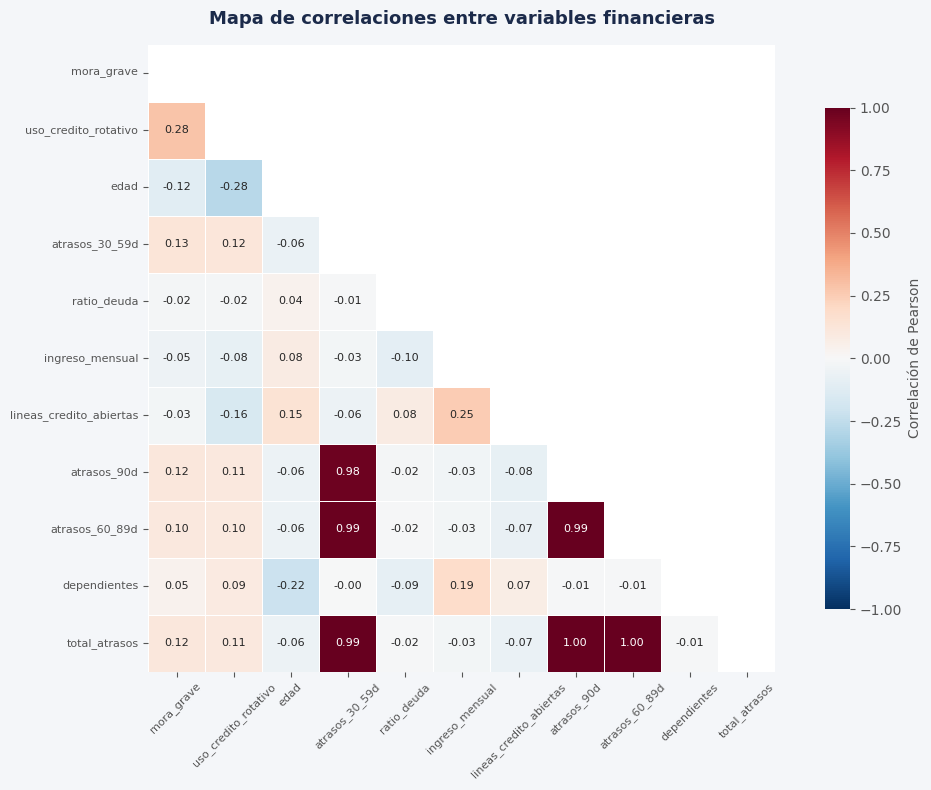

In [ ]:
variables_numericas = [
    "mora_grave", "uso_credito_rotativo", "edad",
    "atrasos_30_59d", "ratio_deuda", "ingreso_mensual",
    "lineas_credito_abiertas", "atrasos_90d",
    "atrasos_60_89d", "dependientes", "total_atrasos"
]

corr = df[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor(GRIS_FONDO)

mascara = np.triu(np.ones_like(corr, dtype=bool))  # solo triángulo inferior

sns.heatmap(
    corr, mask=mascara, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    ax=ax, square=True, linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"},
    annot_kws={"size": 8}
)

ax.set_title("Mapa de correlaciones entre variables financieras", pad=15)
ax.tick_params(axis="x", rotation=45, labelsize=8)
ax.tick_params(axis="y", rotation=0,  labelsize=8)
print(" 📊 Gráfico generado")    
plt.tight_layout()
plt.savefig("../reports/03_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

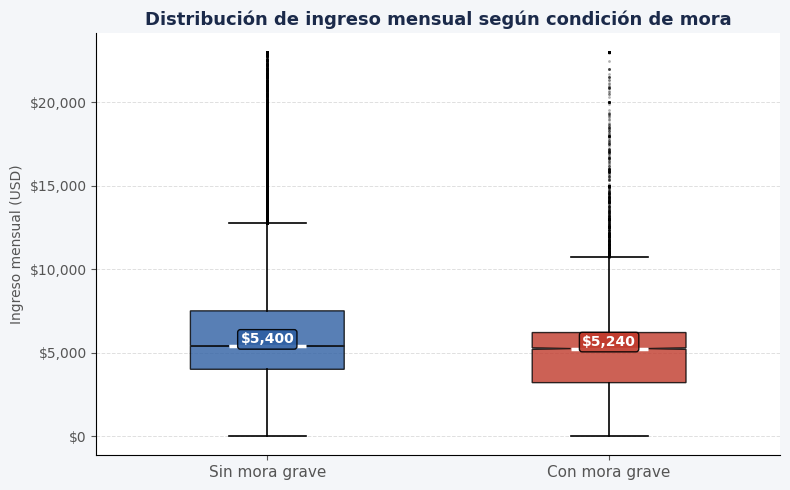

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(GRIS_FONDO)

data_plot = [
    df[df["mora_grave"] == 0]["ingreso_mensual"].dropna(),
    df[df["mora_grave"] == 1]["ingreso_mensual"].dropna()
]

bp = ax.boxplot(
    data_plot,
    patch_artist=True,
    notch=True,
    widths=0.45,
    medianprops=dict(color="white", linewidth=2.5),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker=".", markersize=2, alpha=0.3)
)

colores_box = [AZUL_MEDIO, ROJO_MORA]
for patch, color in zip(bp["boxes"], colores_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Sin mora grave", "Con mora grave"], fontsize=11)
ax.set_title("Distribución de ingreso mensual según condición de mora")
ax.set_ylabel("Ingreso mensual (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${int(x):,}"))
ax.grid(axis="y", zorder=0)

# Medianas anotadas
for i, dataset in enumerate(data_plot, start=1):
    mediana = dataset.median()
    ax.text(i, mediana + 150, f"${mediana:,.0f}",
            ha="center", fontsize=10, fontweight="bold", color="white",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=colores_box[i-1], alpha=0.9))
print(" 📊 Gráfico generado")    
plt.tight_layout()
plt.savefig("../reports/04_ingreso_vs_mora.png", dpi=150, bbox_inches="tight")
plt.show()

## 📌 Hallazgos clave del análisis exploratorio

| # | Hallazgo | Implicación para el negocio |
|---|----------|----------------------------|
| 1 | Los clientes de riesgo **Alto** tienen una tasa de mora del **39%**, vs **1.9%** en riesgo Bajo | El modelo de segmentación discrimina correctamente |
| 2 | Los clientes con mora son **más jóvenes** en mediana (~2-4 años menos) | Los jóvenes representan mayor riesgo relativo |
| 3 | El **ingreso mensual** de clientes en mora es menor en mediana | La capacidad de pago es un factor diferenciador clave |
| 4 | `total_atrasos` y `mora_grave` tienen la **correlación más alta** | Las variables de atraso histórico son las más predictivas |
| 5 | `uso_credito_rotativo` elevado correlaciona con mora | La sobre-utilización de tarjetas es señal temprana de riesgo |